In [37]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.9.3.0 --force-reinstall

Found existing installation: mediapipe 0.10.13
Uninstalling mediapipe-0.10.13:
  Successfully uninstalled mediapipe-0.10.13
ERROR: Could not find a version that satisfies the requirement mediapipe==0.9.3.0 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32, 0.10.33)
ERROR: No matching distribution found for mediapipe==0.9.3.0


In [38]:
!pip install mediapipe==0.10.13

  Using cached mediapipe-0.10.13-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.13-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.6 MB)


In [39]:
import mediapipe as mp
print(mp.__version__)  # 0.9.3.0 이 출력되어야 함

0.10.13


In [40]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')
print("셀 2 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
셀 2 완료


In [41]:
#라이브러리 임포트
import os
import zipfile
import urllib.request
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib as plt
print("셀 3 완료")

셀 3 완료


In [42]:
# ──────────────────────────────────────────────
# ZIP 파일 URL 및 저장 경로 설정
# ──────────────────────────────────────────────

FILE_IDS = [
    "1f3UEJ45UHqcPXY2IoPe-O7ItWVdEDpLz",   # 사이드    - 성은
    "1xwkhGSERd6yaES47ZBxtS7auDdFdVzWE",   # 오버핸드  - 용인
    "1wS_yOM378-y6JNB1-76iR5DOgrU1apSo",   # 언더      - 준선
]

DOWNLOAD_DIR = "/content/zips"
EXTRACT_DIR  = "/content/dataset"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR,  exist_ok=True)

def gdrive_url(file_id: str) -> str:
    """파일 ID → 직접 다운로드 URL 변환"""
    return f"https://drive.google.com/uc?export=download&id={file_id}"

def download_and_extract(file_id: str, download_dir: str, extract_dir: str) -> str:
    """Drive 파일 ID로 ZIP을 내려받고 압축 해제 후 경로를 반환합니다."""
    url      = gdrive_url(file_id)
    zip_path = os.path.join(download_dir, f"{file_id}.zip")
    dest     = os.path.join(extract_dir, file_id)

    print(f"[다운로드] ID: {file_id}")
    urllib.request.urlretrieve(url, zip_path)

    print(f"[압축 해제] → {dest}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(dest)

    return dest

extract_paths = []
for fid in FILE_IDS:
    path = download_and_extract(fid, DOWNLOAD_DIR, EXTRACT_DIR)
    extract_paths.append(path)

print("\n✅ 모든 ZIP 처리 완료")
for p in extract_paths:
    print(" -", p)

print("셀 4 완료")

[다운로드] ID: 1f3UEJ45UHqcPXY2IoPe-O7ItWVdEDpLz
[압축 해제] → /content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdEDpLz
[다운로드] ID: 1xwkhGSERd6yaES47ZBxtS7auDdFdVzWE
[압축 해제] → /content/dataset/1xwkhGSERd6yaES47ZBxtS7auDdFdVzWE
[다운로드] ID: 1wS_yOM378-y6JNB1-76iR5DOgrU1apSo
[압축 해제] → /content/dataset/1wS_yOM378-y6JNB1-76iR5DOgrU1apSo

✅ 모든 ZIP 처리 완료
 - /content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdEDpLz
 - /content/dataset/1xwkhGSERd6yaES47ZBxtS7auDdFdVzWE
 - /content/dataset/1wS_yOM378-y6JNB1-76iR5DOgrU1apSo
셀 4 완료


In [43]:
# 지원 확장자
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def collect_images(root_dirs: list) -> list:
    """여러 디렉토리에서 이미지 파일 경로를 재귀적으로 수집합니다."""
    paths = []
    for root in root_dirs:
        for p in Path(root).rglob("*"):
            if p.suffix.lower() in IMAGE_EXTS:
                paths.append(str(p))
    return sorted(paths)

image_paths = collect_images(extract_paths)
print(f"총 이미지 수: {len(image_paths)}")
print("셀 5 완료")

총 이미지 수: 60
셀 5 완료


In [44]:
from mediapipe.python.solutions.hands import Hands, HandLandmark, HAND_CONNECTIONS
from mediapipe.python.solutions.drawing_utils import draw_landmarks, DrawingSpec

# 기본 detector
hands_detector = Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5,
)

# 신뢰도 완화 detector (전신 사진 대응)
hands_detector_loose = Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.1,
)

LANDMARK_NAMES = [lm.name for lm in HandLandmark]
print("랜드마크 목록:", LANDMARK_NAMES)

print("셀 6 완료")

랜드마크 목록: ['WRIST', 'THUMB_CMC', 'THUMB_MCP', 'THUMB_IP', 'THUMB_TIP', 'INDEX_FINGER_MCP', 'INDEX_FINGER_PIP', 'INDEX_FINGER_DIP', 'INDEX_FINGER_TIP', 'MIDDLE_FINGER_MCP', 'MIDDLE_FINGER_PIP', 'MIDDLE_FINGER_DIP', 'MIDDLE_FINGER_TIP', 'RING_FINGER_MCP', 'RING_FINGER_PIP', 'RING_FINGER_DIP', 'RING_FINGER_TIP', 'PINKY_MCP', 'PINKY_PIP', 'PINKY_DIP', 'PINKY_TIP']
셀 6 완료


In [45]:
from mediapipe.python.solutions.hands import Hands, HandLandmark, HAND_CONNECTIONS
from mediapipe.python.solutions.drawing_utils import draw_landmarks
from mediapipe.python.solutions.pose import Pose, PoseLandmark

LANDMARK_NAMES = [lm.name for lm in HandLandmark]

pose_detector = Pose(
    static_image_mode=True,
    model_complexity=2,
    min_detection_confidence=0.3,
)

hands_detector_loose = Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.1,
)

# padding을 0.7
def extract_landmarks_via_pose(image_path: str, pose_det, hand_det, padding: float = 0.7) -> list | None:
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None

    H, W = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pose_result = pose_det.process(img_rgb)
    if not pose_result.pose_landmarks:
        return None

    lms = pose_result.pose_landmarks.landmark
    wrist_ids = [PoseLandmark.LEFT_WRIST, PoseLandmark.RIGHT_WRIST]
    all_rows = []

    for wrist_id in wrist_ids:
        wrist = lms[wrist_id]
        if wrist.visibility < 0.3:
            continue

        cx, cy = int(wrist.x * W), int(wrist.y * H)
        hand_size = int(H * 0.15)
        pad = int(hand_size * padding)

        x1, y1 = max(0, cx-pad), max(0, cy-pad)
        x2, y2 = min(W, cx+pad), min(H, cy+pad)
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop_rgb = cv2.cvtColor(cv2.resize(crop, (256, 256)), cv2.COLOR_BGR2RGB)
        hand_result = hand_det.process(crop_rgb)
        if not hand_result.multi_hand_landmarks:
            continue

        for hand_idx, hand_landmarks in enumerate(hand_result.multi_hand_landmarks):
            handedness = hand_result.multi_handedness[hand_idx].classification[0].label
            for lm_idx, lm in enumerate(hand_landmarks.landmark):
                all_rows.append({
                    "image_path" : image_path,
                    "hand_index" : hand_idx,
                    "handedness" : handedness,
                    "landmark_id": lm_idx,
                    "landmark"   : LANDMARK_NAMES[lm_idx],
                    "x"          : lm.x,
                    "y"          : lm.y,
                    "z"          : lm.z,
                    "wrist_cx"   : cx,
                    "wrist_cy"   : cy,
                })

    return all_rows if all_rows else None

# 전체 재실행
all_records = []
fail_count  = 0

for i, path in enumerate(image_paths):
    records = extract_landmarks_via_pose(path, pose_detector, hands_detector_loose)
    if records is None:
        fail_count += 1
    else:
        all_records.extend(records)

print(f"✅ 완료 — 성공: {len(image_paths) - fail_count}, 실패: {fail_count}")
print(f"총 랜드마크: {len(all_records)}")


print("셀 7 완료")

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ 완료 — 성공: 45, 실패: 15
총 랜드마크: 1302
셀 7 완료


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


실패 원인 분류:
  pose_미감지: 1장
  손목_가시성_낮음: 1장
  hands_미감지: 13장


/tmp/ipykernel_10367/3648778998.py:72: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10367/3648778998.py:72: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10367/3648778998.py:72: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10367/3648778998.py:72: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10367/3648778998.py:72: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10367/3648778998.py:72: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10367/3648778998.py:72: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tigh

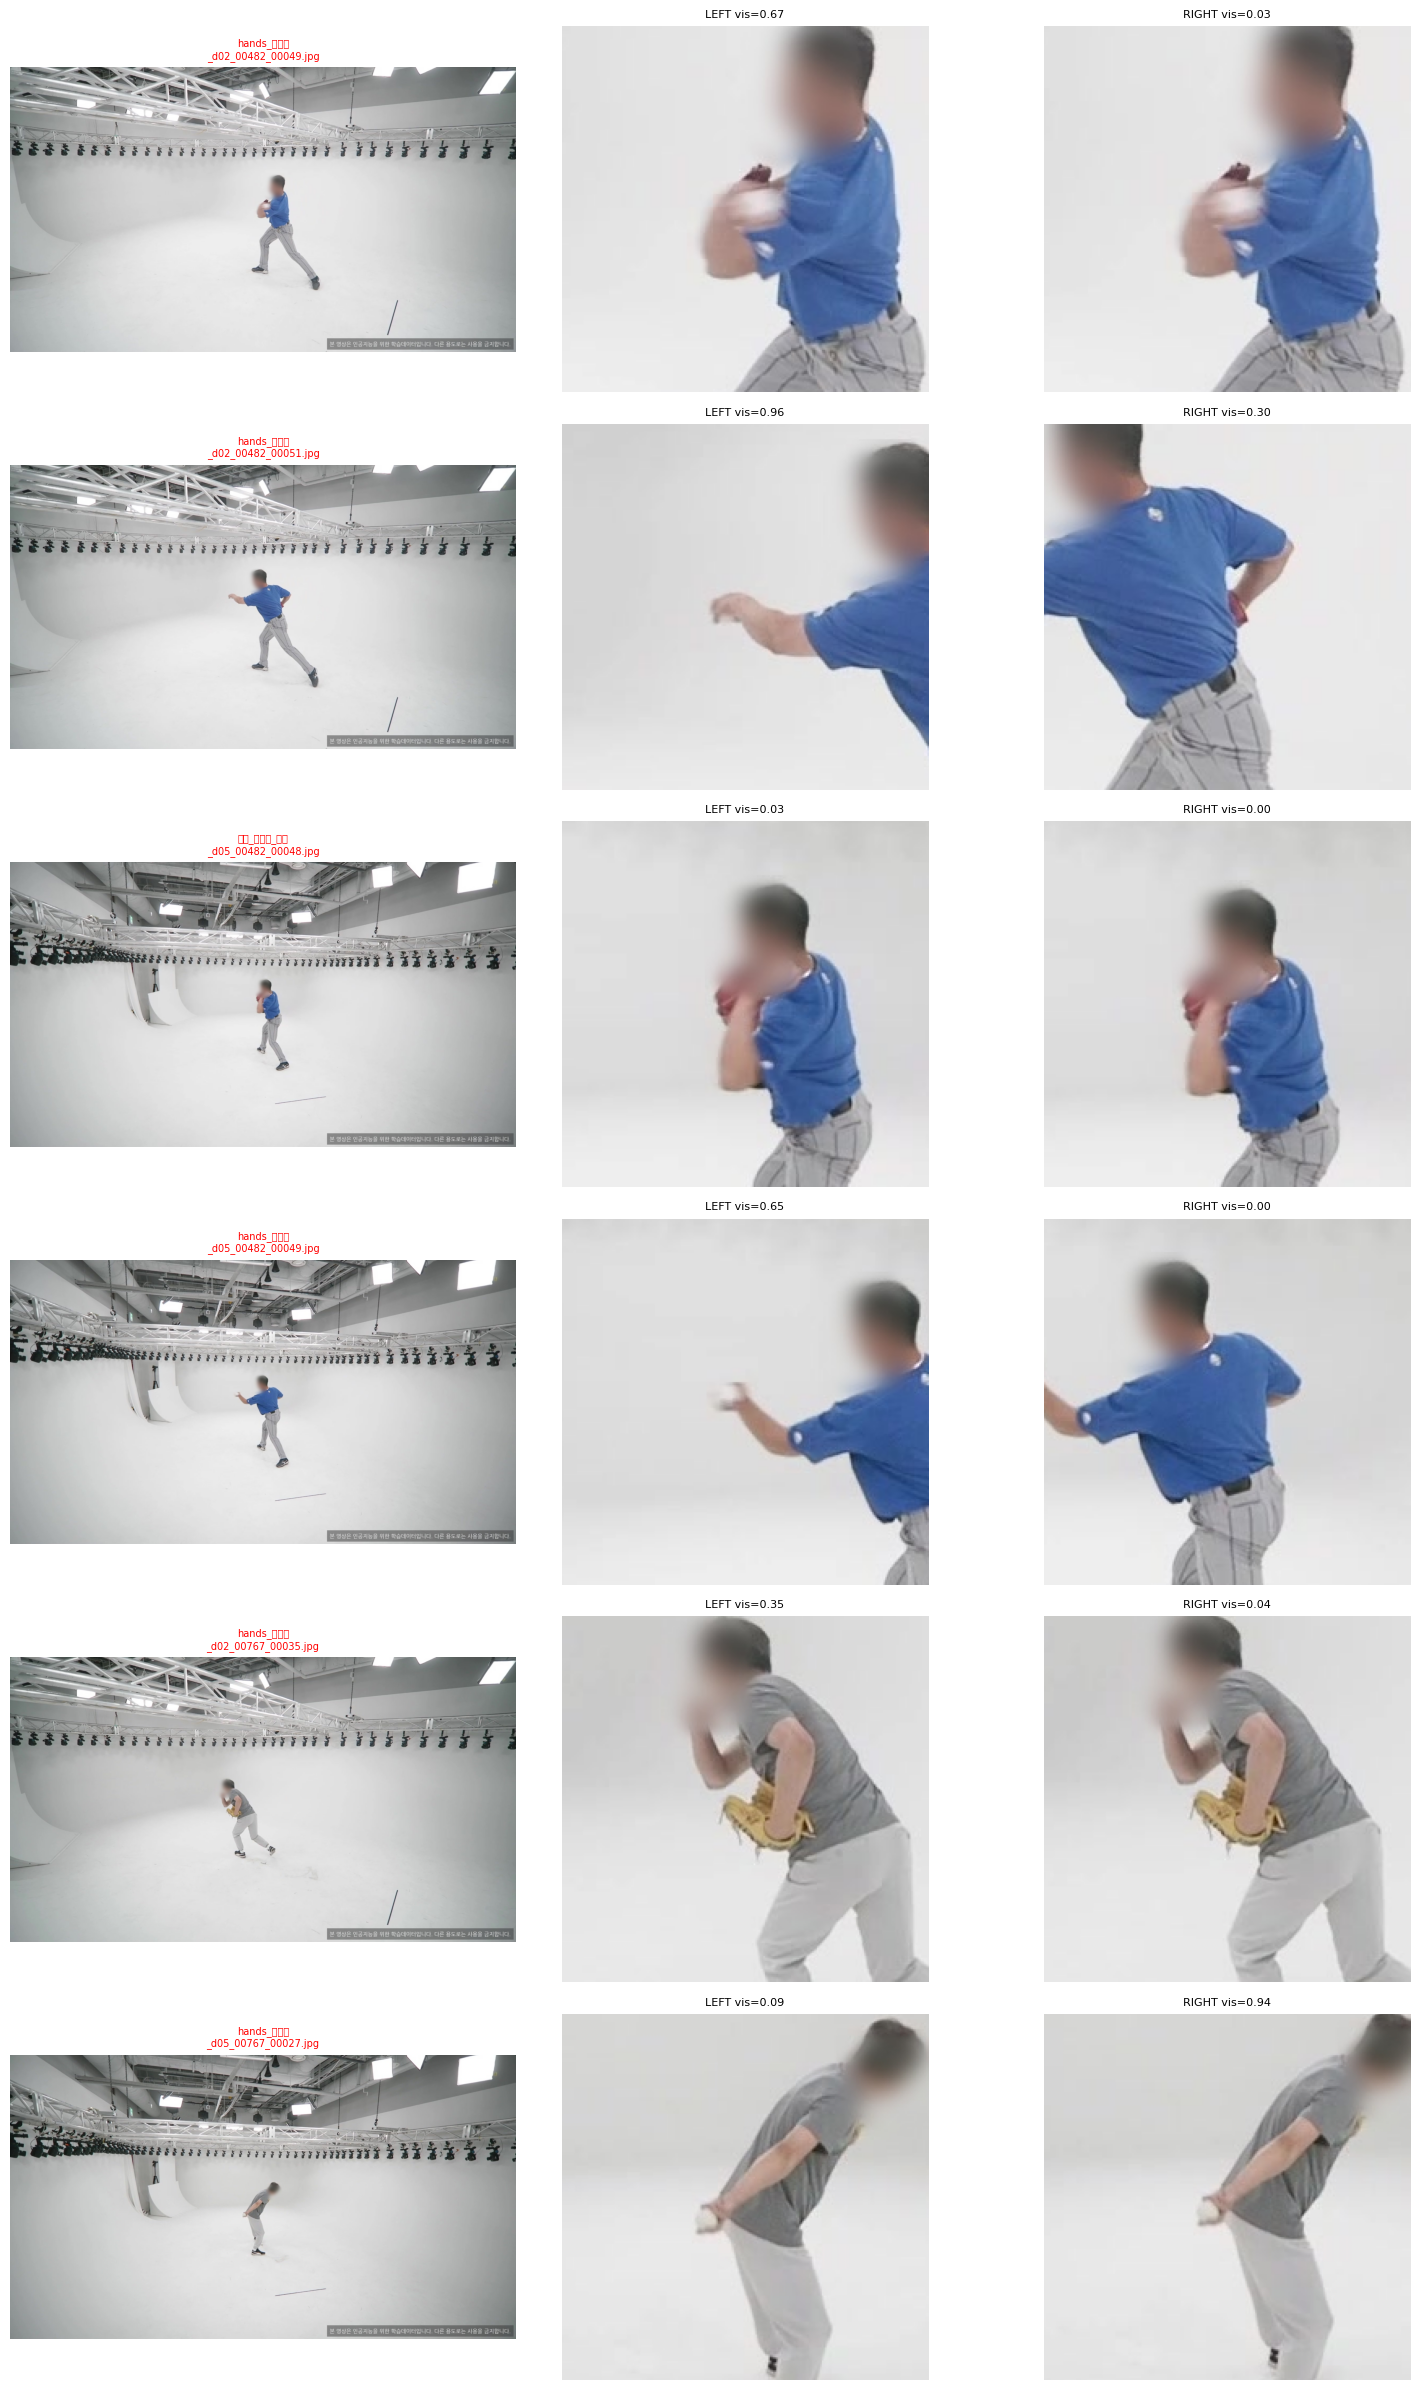

In [52]:
fail_reasons = {"pose_미감지": 0, "손목_가시성_낮음": 0, "hands_미감지": 0}
fail_paths = []

for path in image_paths:
    img_bgr = cv2.imread(path)
    H, W = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pose_result = pose_detector.process(img_rgb)
    if not pose_result.pose_landmarks:
        fail_reasons["pose_미감지"] += 1
        fail_paths.append((path, "pose_미감지"))
        continue

    lms = pose_result.pose_landmarks.landmark
    visible_wrists = [lms[w] for w in [PoseLandmark.LEFT_WRIST, PoseLandmark.RIGHT_WRIST]
                      if lms[w].visibility >= 0.3]
    if not visible_wrists:
        fail_reasons["손목_가시성_낮음"] += 1
        fail_paths.append((path, "손목_가시성_낮음"))
        continue

    detected = False
    for wrist in visible_wrists:
        cx, cy = int(wrist.x * W), int(wrist.y * H)
        pad = int(H * 0.15 * 0.7)
        crop = img_bgr[max(0,cy-pad):min(H,cy+pad), max(0,cx-pad):min(W,cx+pad)]
        if crop.size == 0:
            continue
        crop_rgb = cv2.cvtColor(cv2.resize(crop, (256,256)), cv2.COLOR_BGR2RGB)
        if hands_detector_loose.process(crop_rgb).multi_hand_landmarks:
            detected = True
            break
    if not detected:
        fail_reasons["hands_미감지"] += 1
        fail_paths.append((path, "hands_미감지"))

print("실패 원인 분류:")
for reason, count in fail_reasons.items():
    print(f"  {reason}: {count}장")

# 실패 이미지 + crop 시각화
fig, axes = plt.subplots(min(len(fail_paths), 6), 3, figsize=(15, 4 * min(6, len(fail_paths))))
if len(fail_paths) == 1:
    axes = [axes]

for row_idx, (path, reason) in enumerate(fail_paths[:6]):
    img_bgr = cv2.imread(path)
    H, W = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pose_result = pose_detector.process(img_rgb)
    lms = pose_result.pose_landmarks.landmark if pose_result.pose_landmarks else None

    axes[row_idx][0].imshow(img_rgb)
    axes[row_idx][0].set_title(f"{reason}\n{Path(path).name[-20:]}", fontsize=7, color="red")
    axes[row_idx][0].axis("off")

    for col_idx, wrist_id in enumerate([PoseLandmark.LEFT_WRIST, PoseLandmark.RIGHT_WRIST]):
        if lms is None:
            axes[row_idx][col_idx+1].axis("off")
            continue
        wrist = lms[wrist_id]
        cx, cy = int(wrist.x * W), int(wrist.y * H)
        pad = int(H * 0.15 * 0.7)
        crop = img_bgr[max(0,cy-pad):min(H,cy+pad), max(0,cx-pad):min(W,cx+pad)]
        label = "LEFT" if wrist_id == PoseLandmark.LEFT_WRIST else "RIGHT"
        if crop.size > 0:
            axes[row_idx][col_idx+1].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[row_idx][col_idx+1].set_title(f"{label} vis={wrist.visibility:.2f}", fontsize=8)
        axes[row_idx][col_idx+1].axis("off")

plt.tight_layout()
plt.show()

print("셀 8 완료")

In [47]:
# ── 타일 방식 단일 이미지 테스트 ──
# ── Pose + Hands 방식 테스트 ──
test_result = extract_landmarks_via_pose(image_paths[0], pose_detector, hands_detector_loose)
print("결과:", f"✅ 랜드마크 {len(test_result)}개 감지됨" if test_result else "❌ 감지 안됨")


# 감지됐으면 시각화
if test_result:
    print(f"✅ 랜드마크 {len(test_result)}개 감지됨")
else:
    print("❌ 여전히 감지 안됨")

print("셀 9 완료")

결과: ✅ 랜드마크 42개 감지됨
✅ 랜드마크 42개 감지됨
셀 9 완료


In [48]:
all_records = []
fail_count  = 0

for i, path in enumerate(image_paths):
    records = extract_landmarks_via_pose(path, pose_detector, hands_detector_loose)

    if records is None:
        fail_count += 1
    else:
        all_records.extend(records)

    if (i + 1) % 100 == 0 or (i + 1) == len(image_paths):
        print(f"[{i+1}/{len(image_paths)}] 누적 랜드마크: {len(all_records)}, 실패: {fail_count}")

print(f"\n✅ 완료 — 성공: {len(image_paths) - fail_count}, 실패: {fail_count}")

print("셀 10 완료")


[60/60] 누적 랜드마크: 1302, 실패: 15

✅ 완료 — 성공: 45, 실패: 15
셀 10 완료


In [ ]:
# DataFrame 생성
df = pd.DataFrame(all_records)
print(df.shape)
df.head()
#print("셀 10 완료")

(1302, 10)


,image_path,hand_index,handedness,landmark_id,landmark,x,y,z,wrist_cx,wrist_cy
0,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,0,Left,0,WRIST,0.490070,0.502337,-2.364422e-07,1256,607
1,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,0,Left,1,THUMB_CMC,0.521318,0.515172,2.046010e-03,1256,607
2,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,0,Left,2,THUMB_MCP,0.535439,0.538092,1.588700e-03,1256,607
3,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,0,Left,3,THUMB_IP,0.532237,0.556507,8.129049e-04,1256,607
4,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,0,Left,4,THUMB_TIP,0.523427,0.566493,4.583200e-04,1256,607


In [ ]:
# ──────────────────────────────────────────────
# 라벨링 ZIP 파일 ID 입력 (CSV 3개 포함된 ZIP)
# ──────────────────────────────────────────────

LABEL_ZIP_ID  = "1X2n66SrERg0c_RS0jts07rQOqD312nlX"
LABEL_DL_DIR  = "/content/label_zip"
LABEL_EXT_DIR = "/content/labels"

os.makedirs(LABEL_DL_DIR,  exist_ok=True)
os.makedirs(LABEL_EXT_DIR, exist_ok=True)

# 다운로드 및 압축 해제
zip_path = os.path.join(LABEL_DL_DIR, f"{LABEL_ZIP_ID}.zip")
urllib.request.urlretrieve(gdrive_url(LABEL_ZIP_ID), zip_path)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(LABEL_EXT_DIR)
print("✅ 라벨 ZIP 압축 해제 완료")

# CSV 3개 로드 후 합치기
csv_paths = list(Path(LABEL_EXT_DIR).rglob("*.csv"))
print(f"발견된 CSV: {len(csv_paths)}개")
for p in csv_paths:
    print(" -", p)

df_label = pd.concat([pd.read_csv(p) for p in csv_paths], ignore_index=True)
print(f"\n라벨 데이터 shape: {df_label.shape}")
df_label.head()

print("셀 11 완료")

✅ 라벨 ZIP 압축 해제 완료
발견된 CSV: 3개
 - /content/labels/준선.csv
 - /content/labels/용인.csv
 - /content/labels/성은.csv

라벨 데이터 shape: (60, 48)


,image_id,image_name,width,height,WRIST_x,WRIST_y,THUMB_CMC_x,THUMB_CMC_y,THUMB_MCP_x,THUMB_MCP_y,...,PINKY_MCP_x,PINKY_MCP_y,PINKY_PIP_x,PINKY_PIP_y,PINKY_DIP_x,PINKY_DIP_y,PINKY_TIP_x,PINKY_TIP_y,INDEX_FINGER_TIP_2_x,INDEX_FINGER_TIP_2_y
0,0,baseball_ra_pu_d02_00767_00026.jpg,1920,1080,1050.13,675.20,NaN,NaN,1043.13,692.10,...,1060.73,693.10,NaN,NaN,NaN,NaN,1051.23,691.10,NaN,NaN
1,1,baseball_ra_pu_d02_00767_00027.jpg,1920,1080,1048.33,637.10,NaN,NaN,1044.53,650.20,...,1061.93,649.70,NaN,NaN,NaN,NaN,1059.93,650.60,NaN,NaN
2,2,baseball_ra_pu_d02_00767_00028.jpg,1920,1080,1055.33,578.80,NaN,NaN,1052.68,591.48,...,1071.80,576.80,NaN,NaN,NaN,NaN,1069.20,576.00,NaN,NaN
3,3,baseball_ra_pu_d02_00767_00029.jpg,1920,1080,1076.48,562.78,NaN,NaN,1092.08,562.98,...,1085.88,546.48,NaN,NaN,NaN,NaN,1086.98,555.28,NaN,NaN
4,4,baseball_ra_pu_d02_00767_00030.jpg,1920,1080,1077.48,557.88,NaN,NaN,1084.58,547.28,...,1080.68,543.18,NaN,NaN,NaN,NaN,1088.08,543.88,NaN,NaN


In [ ]:
# ──────────────────────────────────────────────
# MediaPipe 결과(all_records)를 라벨과 동일한 wide 형식으로 변환
# x,y가 0~1 정규화 좌표이므로 픽셀 좌표로 변환
# ──────────────────────────────────────────────

df_mp = pd.DataFrame(all_records)

# 이미지별 width, height 추가
def get_img_size(path):
    img = cv2.imread(path)
    if img is None:
        return 1920, 1080
    return img.shape[1], img.shape[0]  # W, H

# wide format으로 피벗
df_mp_wide = df_mp.pivot_table(
    index="image_path",
    columns="landmark",
    values=["x", "y"],
    aggfunc="first"
).reset_index()

# 컬럼명 정리: (x, WRIST) → WRIST_x
df_mp_wide.columns = [
    f"{lm}_{coord}" if lm != "" else "image_path"
    for coord, lm in df_mp_wide.columns
]

# image_name 컬럼 추가 (파일명만)
df_mp_wide["image_name"] = df_mp_wide["image_path"].apply(lambda p: Path(p).name)

# 픽셀 좌표로 변환
size_map = {p: get_img_size(p) for p in df_mp["image_path"].unique()}
df_mp_wide["width"]  = df_mp_wide["image_path"].map(lambda p: size_map[p][0])
df_mp_wide["height"] = df_mp_wide["image_path"].map(lambda p: size_map[p][1])

for col in df_mp_wide.columns:
    if col.endswith("_x"):
        df_mp_wide[col] = df_mp_wide[col] * df_mp_wide["width"]
    elif col.endswith("_y"):
        df_mp_wide[col] = df_mp_wide[col] * df_mp_wide["height"]

print(f"MediaPipe wide shape: {df_mp_wide.shape}")
df_mp_wide.head()

print("셀 12 완료")

MediaPipe wide shape: (45, 46)


,image_path,INDEX_FINGER_DIP_x,INDEX_FINGER_MCP_x,INDEX_FINGER_PIP_x,INDEX_FINGER_TIP_x,MIDDLE_FINGER_DIP_x,MIDDLE_FINGER_MCP_x,MIDDLE_FINGER_PIP_x,MIDDLE_FINGER_TIP_x,PINKY_DIP_x,...,RING_FINGER_PIP_y,RING_FINGER_TIP_y,THUMB_CMC_y,THUMB_IP_y,THUMB_MCP_y,THUMB_TIP_y,WRIST_y,image_name,width,height
0,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,1027.285423,1017.441444,1033.357773,1019.010429,987.750320,983.527222,992.029037,980.665512,930.736713,...,627.031031,599.859824,556.385765,601.027679,581.139250,611.812027,542.523808,baseball_ra_ps_d02_00482_00042.jpg,1920,1080
1,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,1075.946388,1088.680229,1093.992691,1059.937363,1036.287689,1049.587097,1049.225006,1022.346039,956.909409,...,606.813076,583.868408,540.125206,575.868773,558.952188,585.963171,539.745083,baseball_ra_ps_d02_00482_00043.jpg,1920,1080
2,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,1144.118729,1120.241547,1161.410408,1119.036255,1124.057693,1093.921051,1138.626823,1099.713707,1028.804398,...,636.061664,611.964848,544.875998,580.689926,557.033229,599.923167,557.380843,baseball_ra_ps_d02_00482_00044.jpg,1920,1080
3,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,1119.065323,1083.816261,1108.587685,1109.510078,1205.030251,1123.272057,1198.843575,1185.703468,1142.348442,...,611.029508,605.930650,607.412517,637.860568,634.085476,629.106803,566.798551,baseball_ra_ps_d02_00482_00045.jpg,1920,1080
4,/content/dataset/1f3UEJ45UHqcPXY2IoPe-O7ItWVdE...,1210.116348,1134.482231,1215.532150,1185.714569,1221.278343,1156.946640,1231.965752,1194.155846,1224.099426,...,663.546431,695.822740,596.101277,677.261746,643.111217,703.423648,553.151278,baseball_ra_ps_d02_00482_00046.jpg,1920,1080


In [ ]:
# ──────────────────────────────────────────────
# MP wide 컬럼에 _mp 접미사 먼저 붙이고 merge
# ──────────────────────────────────────────────

# MP wide에 _mp 접미사 추가 (image_name, width, height, image_path 제외)
rename_map = {}
for col in df_mp_wide.columns:
    if col not in ["image_name", "image_path", "width", "height"]:
        rename_map[col] = f"{col}_mp"

df_mp_wide_renamed = df_mp_wide.rename(columns=rename_map)

# merge
df_merged = pd.merge(
    df_label,
    df_mp_wide_renamed,
    on="image_name",
    how="inner"
)
print(f"매칭된 이미지 수: {len(df_merged)}")

# 랜드마크별 유클리드 거리 계산
LANDMARKS = [lm.name for lm in HandLandmark]

for lm in LANDMARKS:
    x_label = df_merged.get(f"{lm}_x")
    y_label = df_merged.get(f"{lm}_y")
    x_mp    = df_merged.get(f"{lm}_x_mp")
    y_mp    = df_merged.get(f"{lm}_y_mp")

    if x_label is None or x_mp is None:
        continue

    df_merged[f"{lm}_dist"] = np.sqrt(
        (x_label - x_mp) ** 2 + (y_label - y_mp) ** 2
    )

dist_cols = [c for c in df_merged.columns if c.endswith("_dist")]
df_merged["mean_dist"] = df_merged[dist_cols].mean(axis=1)

print(f"\n랜드마크별 평균 오차 (픽셀):")
print(df_merged[dist_cols].mean().sort_values())
print(f"\n전체 평균 오차: {df_merged['mean_dist'].mean():.2f}px")

print("셀 13 완료")

매칭된 이미지 수: 45

랜드마크별 평균 오차 (픽셀):
THUMB_CMC_dist             59.230399
RING_FINGER_MCP_dist      216.025395
MIDDLE_FINGER_MCP_dist    216.664647
PINKY_MCP_dist            217.419071
INDEX_FINGER_MCP_dist     219.005045
PINKY_TIP_dist            219.167678
RING_FINGER_TIP_dist      220.727833
MIDDLE_FINGER_TIP_dist    222.634920
THUMB_TIP_dist            223.765428
INDEX_FINGER_TIP_dist     225.148260
THUMB_MCP_dist            234.408745
WRIST_dist                249.670662
MIDDLE_FINGER_PIP_dist    934.825422
THUMB_IP_dist                    NaN
INDEX_FINGER_PIP_dist            NaN
INDEX_FINGER_DIP_dist            NaN
MIDDLE_FINGER_DIP_dist           NaN
RING_FINGER_PIP_dist             NaN
RING_FINGER_DIP_dist             NaN
PINKY_PIP_dist                   NaN
PINKY_DIP_dist                   NaN
dtype: float64

전체 평균 오차: 223.71px


In [ ]:
# ──────────────────────────────────────────────
# 라벨 vs MediaPipe 매칭 상태 확인
# ──────────────────────────────────────────────

label_names = set(df_label["image_name"])
mp_names    = set(df_mp_wide["image_name"])

matched     = label_names & mp_names
only_label  = label_names - mp_names
only_mp     = mp_names - label_names

print(f"라벨 이미지 수    : {len(label_names)}")
print(f"MediaPipe 이미지 수: {len(mp_names)}")
print(f"매칭된 이미지 수  : {len(matched)}")
print(f"라벨에만 있는 이미지: {len(only_label)}")
print(f"MediaPipe에만 있는 이미지: {len(only_mp)}")

# 매칭 안 된 이미지 이름 확인
if only_label:
    print("\n⚠️ 라벨에만 있음 (MediaPipe 실패):")
    for n in sorted(only_label):
        print(" -", n)

if only_mp:
    print("\n⚠️ MediaPipe에만 있음 (라벨 없음):")
    for n in sorted(only_mp):
        print(" -", n)

# 라벨 샘플 image_name 확인
print("\n라벨 image_name 샘플:", df_label["image_name"].values[:3])
print("MP    image_name 샘플:", df_mp_wide["image_name"].values[:3])

print("셀 14 완료")

라벨 이미지 수    : 60
MediaPipe 이미지 수: 45
매칭된 이미지 수  : 45
라벨에만 있는 이미지: 15
MediaPipe에만 있는 이미지: 0

⚠️ 라벨에만 있음 (MediaPipe 실패):
 - baseball_ra_po_d02_00744_00044.jpg
 - baseball_ra_po_d02_00744_00045.jpg
 - baseball_ra_po_d05_00744_00041.jpg
 - baseball_ra_po_d05_00744_00043.jpg
 - baseball_ra_po_d05_00744_00045.jpg
 - baseball_ra_po_d05_00744_00046.jpg
 - baseball_ra_ps_d02_00482_00049.jpg
 - baseball_ra_ps_d02_00482_00051.jpg
 - baseball_ra_ps_d05_00482_00048.jpg
 - baseball_ra_ps_d05_00482_00049.jpg
 - baseball_ra_pu_d02_00767_00035.jpg
 - baseball_ra_pu_d05_00767_00027.jpg
 - baseball_ra_pu_d05_00767_00029.jpg
 - baseball_ra_pu_d05_00767_00033.jpg
 - baseball_ra_pu_d05_00767_00035.jpg

라벨 image_name 샘플: ['baseball_ra_pu_d02_00767_00026.jpg' 'baseball_ra_pu_d02_00767_00027.jpg'
 'baseball_ra_pu_d02_00767_00028.jpg']
MP    image_name 샘플: ['baseball_ra_ps_d02_00482_00042.jpg' 'baseball_ra_ps_d02_00482_00043.jpg'
 'baseball_ra_ps_d02_00482_00044.jpg']


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


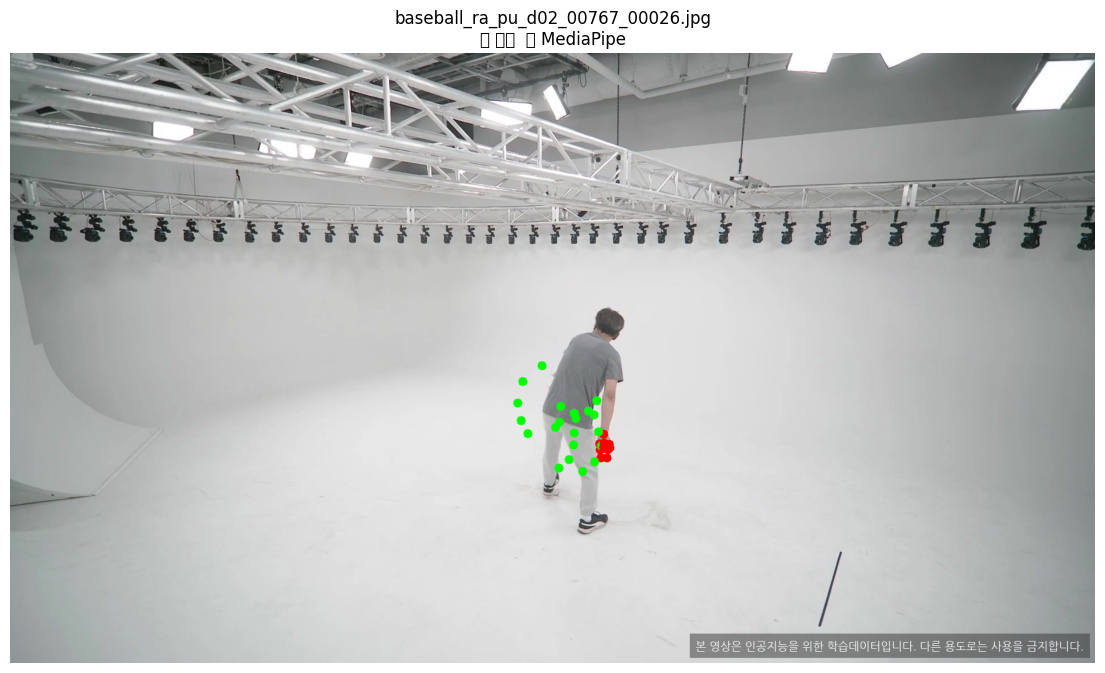

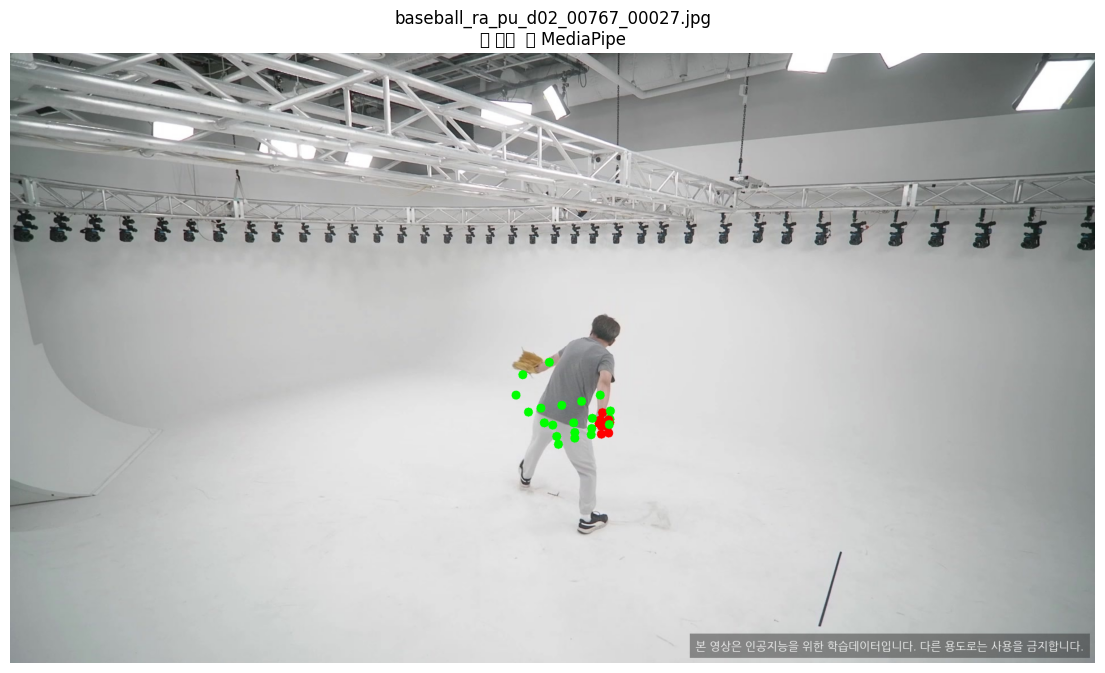

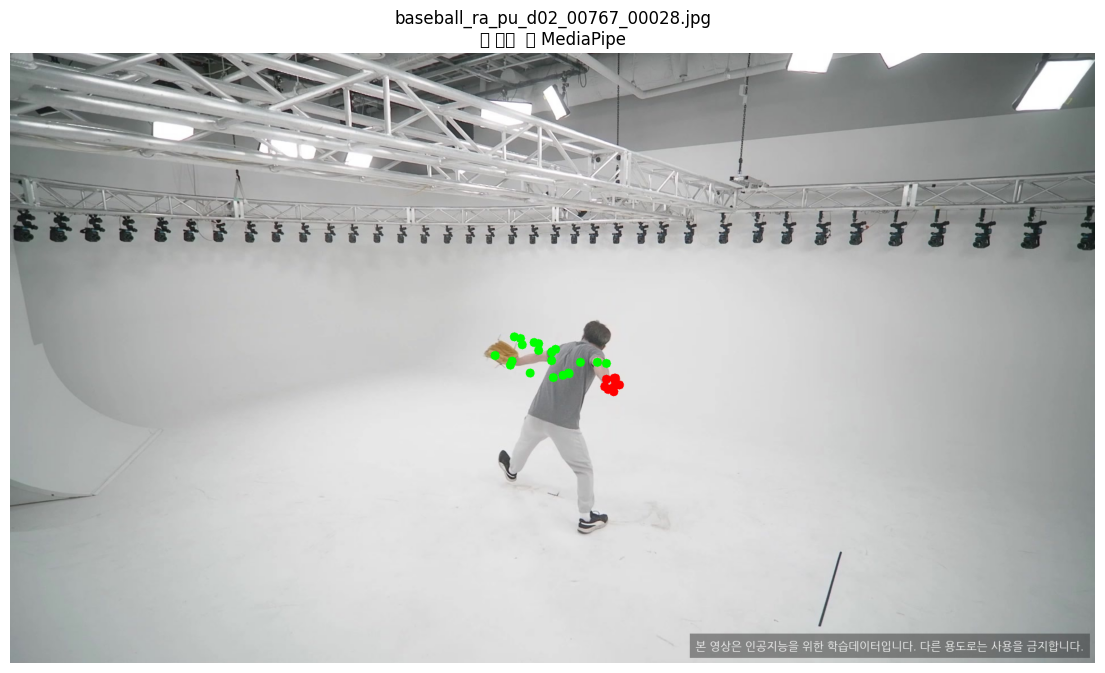

In [71]:
# ──────────────────────────────────────────────
# 한 이미지에 라벨(빨강)과 MediaPipe(초록) 동시 표시
# ──────────────────────────────────────────────

def visualize_comparison(image_name, df_label, df_mp):
    img_path = next((p for p in image_paths if Path(p).name == image_name), None)
    if img_path is None:
        print(f"이미지 없음: {image_name}")
        return

    img_draw = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    row_label = df_label[df_label["image_name"] == image_name]
    row_mp    = df_mp[df_mp["image_name"] == image_name]

    for lm in LANDMARKS:
        # 라벨 좌표 (빨강)
        if f"{lm}_x" in row_label.columns:
            x = row_label[f"{lm}_x"].values[0]
            y = row_label[f"{lm}_y"].values[0]
            if pd.notna(x) and pd.notna(y):
                cv2.circle(img_draw, (int(x), int(y)), 8, (255, 0, 0), -1)

        # MediaPipe 좌표 (초록)
        if f"{lm}_x_mp" in row_mp.columns:
            x = row_mp[f"{lm}_x_mp"].values[0]
            y = row_mp[f"{lm}_y_mp"].values[0]
            if pd.notna(x) and pd.notna(y):
                cv2.circle(img_draw, (int(x), int(y)), 8, (0, 255, 0), -1)

    plt.figure(figsize=(14, 8))
    plt.imshow(img_draw)
    plt.axis("off")
    plt.title(f"{image_name}\n🔴 라벨  🟢 MediaPipe")
    plt.show()

# 매칭된 이미지 중 첫 3장 비교
for name in df_merged["image_name"].values[:3]:
    visualize_comparison(name, df_label, df_mp_wide_renamed)
